In [1]:
import jax
import jax.numpy as jnp
from jax import value_and_grad, jit

import openmm.app as apps
import openmm.unit as unit
from openmm import app
from openmm.app import ForceField

from dmff import Hamiltonian, NeighborList
from dmff.api.xmlio import XMLIO
from dmff.api.paramset import ParamSet
from dmff.operators.templatetype import TemplateATypeOperator
import dmff
from dmff.generators.classical import PeriodicTorsionGenerator

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

from ase.io import read,write
from ase import units

import matplotlib.pyplot as plt
import numpy as np
import copy, os

/Users/srak/apl/imolcryff/DMFF/dmff/admp/qeq.py:33: UserWarning: jaxopt not found, QEQ cannot be used.
  warnings.warn("jaxopt not found, QEQ cannot be used.")


In [2]:
def get_qm_dihedral(g16log):
    import os
    import re
    import cclib
    dihed_cclib = cclib.io.ccread(g16log)
    energy = dihed_cclib.scanenergies
    angle = dihed_cclib.scanparm[0]
    aseatoms = []
    ase_g16log = read(g16log)
    for sc in dihed_cclib.scancoords:
        sc_tmp = ase_g16log.copy()
        for j, atom in enumerate(sc):
            sc_tmp[j].position = sc[j]
        aseatoms.append(sc_tmp)

    zip_lists = zip(angle, energy, aseatoms)
    zip_sort = sorted(zip_lists)
    angle, energy, aseatoms = zip(*zip_sort)
    angle = np.array(angle)
    energy = np.array(energy)
    
    dihedral_energy_kjmol = (energy - energy.min()) / (units.kJ * (units.mol**-1))
    dihedral_angle = angle
    dihedral_aseatoms = aseatoms
    dihed_atomidx = [int(i)-1 for i in re.findall(r'\d+', dihed_cclib.scannames[0])]

    return dihedral_energy_kjmol, dihedral_angle, dihedral_aseatoms, dihed_atomidx

In [3]:
def scan_ff_dihedral(ffxml, top, qm_dangles, qm_dihedatoms, dihed_atidx):
    from openmm.unit import degree, kilojoules_per_mole
    from openmm.app import NoCutoff
    from openmm import PeriodicTorsionForce, LangevinMiddleIntegrator
    from openmm.unit import kelvin, picosecond, picoseconds
    from openmm.app import Simulation, PDBFile
    from openmm.openmm import XmlSerializer
    from openmm.app import ForceField
    dihedral_ffenergy = []

    for i in range(len(qm_dihedatoms)):
        pdb_ase = qm_dihedatoms[i].copy()
        pdb_ase.arrays["atomtypes"] = [i for i in range(len(pdb_ase))]
        write(f"temp_dihed_{i}.pdb", pdb_ase)
        pdb_omm = PDBFile(f"temp_dihed_{i}.pdb")
        atomlist_openmm = [a for a in pdb_omm.topology.atoms()]
        for b in top.bonds():
            a1 = atomlist_openmm[b.atom1.index]
            a2 = atomlist_openmm[b.atom2.index]
            pdb_omm.topology.addBond(a1, a2)

        # relaxed scan
        forcefield = ForceField(ffxml)
        system = forcefield.createSystem(pdb_omm.topology, nonbondedMethod=NoCutoff)
        with open('system.xml', 'w') as output:
            output.write(XmlSerializer.serialize(system))
            
        restraint = PeriodicTorsionForce()
        d1 = dihed_atidx[0]
        d2 = dihed_atidx[1]
        d3 = dihed_atidx[2]
        d4 = dihed_atidx[3]
        restraint.addTorsion(d1,d2,d3,d4, 1, (qm_dangles[i]+180)*degree, 10000*kilojoules_per_mole)
        system.addForce(restraint)
        integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, 0.004*picoseconds)
        simulation = Simulation(pdb_omm.topology, system,integrator)
        simulation.context.setPositions(pdb_omm.positions)
        simulation.minimizeEnergy()
        state = simulation.context.getState(getPositions=True, getEnergy=True)
        with open(f"temp_dihed_{i}.pdb", 'w') as output:
            PDBFile.writeFile(simulation.topology, state.getPositions(), output)

        pdb_omm = PDBFile(f"temp_dihed_{i}.pdb")
        system = forcefield.createSystem(pdb_omm.topology,nonbondedMethod=NoCutoff)
        for j, f in enumerate(system.getForces()):
            f.setForceGroup(j)
            integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, 0.004*picoseconds)
            simulation = Simulation(pdb_omm.topology, system, integrator)
            simulation.context.setPositions(pdb_omm.positions)
        
        potential_energies = []
        for gi, f in enumerate(system.getForces()):
            state = simulation.context.getState(getEnergy=True, groups={gi})
            # print(f.getName(), state.getPotentialEnergy())
            potential_energies.append(state.getPotentialEnergy().real)
        
        dihedral_ffenergy.append(sum(potential_energies))

    ff_pot = np.array(dihedral_ffenergy)
    ff_pot_kjmol = (ff_pot - ff_pot.min())
    return ff_pot_kjmol

# Plot dihedral potential profile

In [4]:
ff = Hamiltonian("dmc.xml")
ff.getParameters().to_jax()
paramset0 = ff.getParameters()

pdbfile = app.PDBFile("dmc.pdb")
top = pdbfile.topology
potentials = ff.createPotential(top)
efunc = potentials.getPotentialFunc()

io = XMLIO()
io.loadXML("dmc.xml")
ffinfo = io.parseXML()
topdata = dmff.DMFFTopology(top)
operator = TemplateATypeOperator(ffinfo)
operator.operate(topdata)
for na, a in enumerate(topdata._meta):
    print(a)
paramset_dihed = ParamSet()
torsion_gen = PeriodicTorsionGenerator(ffinfo, paramset_dihed)

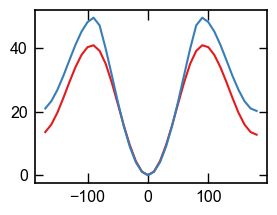

In [5]:
qm_pot_kjmol, qm_angle, qm_dihedatoms, dihed_atidx = get_qm_dihedral("dmc_dihed_0.log")
ff_pot_kjmol = scan_ff_dihedral("dmc.xml", top, qm_angle, qm_dihedatoms, dihed_atidx)
plt.plot(qm_angle, qm_pot_kjmol, label="QM")
plt.plot(qm_angle, ff_pot_kjmol, label="FF")

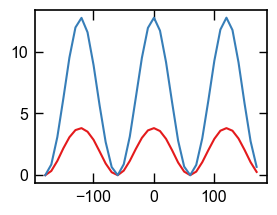

In [6]:
qm_pot_kjmol, qm_angle, qm_dihedatoms, dihed_atidx = get_qm_dihedral("dmc_dihed_2.log")
ff_pot_kjmol = scan_ff_dihedral("dmc.xml", top, qm_angle, qm_dihedatoms, dihed_atidx)

plt.plot(qm_angle, qm_pot_kjmol, label="QM")
plt.plot(qm_angle, ff_pot_kjmol, label="FF")

# Opt dihedral potential

In [7]:
@jit
def MSELoss(params0: ParamSet, ffparams, positions, box, pairs, gt_Etot):
    kT = 2.494 # 300 K = 2.494 kJ/mol
    assert len(positions) == len(gt_Etot)
    assert len(positions) == len(pairs)
    
    gt_Etot = gt_Etot - gt_Etot.min()
    gt_Etot = jnp.array(gt_Etot)
    weights_pts = jnp.piecewise(gt_Etot, [gt_Etot<25, gt_Etot>=25], [lambda x: jnp.array(1.0), lambda x: jnp.exp(-(x-25)/kT)])
    npts = len(weights_pts)
    
    # setting up params for all calculators
    params_dihed = {} 
    params_dihed["PeriodicTorsionForce"] = {}
    params_dihed["PeriodicTorsionForce"]["proper_phase"] = params0["PeriodicTorsionForce"]["proper_phase"]
    params_dihed["PeriodicTorsionForce"]["proper_k"] = params0["PeriodicTorsionForce"]["proper_k"]

    p = copy.deepcopy(ffparams)
    p['PeriodicTorsionForce']["proper_phase"] = params_dihed["PeriodicTorsionForce"]["proper_phase"]
    p['PeriodicTorsionForce']["proper_k"] = params_dihed["PeriodicTorsionForce"]["proper_k"]

    # calculate each points, only the short range and damping components
    totene_ff = jnp.zeros(npts)
    for ipt in range(npts):
        totene_ff = totene_ff.at[ipt].set(efunc(positions[ipt], box, pairs[ipt], p))
    
    totene_ff = totene_ff - totene_ff.min()
        
    dE = totene_ff - gt_Etot
    mse = dE**2 * weights_pts / jnp.sum(weights_pts)
    mse = jnp.sum(mse)

    return mse

def add_grad(grad1:ParamSet, grad2:ParamSet):
    for k in grad1.parameters.keys():
        for t in grad1.parameters[k].keys():
            grad1.parameters[k][t] += grad2.parameters[k][t]
    return ParamSet(grad1.parameters, grad1.mask)

In [8]:
def get_relaxedcoord_dihedconst(top, positions_ary, dihed_atomid, dihed_angle, ffxml):
    from openmm.unit import degree, kilojoules_per_mole, kelvin, picosecond, picoseconds
    from openmm.app import NoCutoff, Simulation
    from openmm import PeriodicTorsionForce, LangevinMiddleIntegrator
    from openmm.app import PDBFile
    positions_list = []
    for i_angle, angle_deg in enumerate(dihed_angle):
        forcefield = ForceField(ffxml)
        system = forcefield.createSystem(top, nonbondedMethod=NoCutoff)
        restraint = PeriodicTorsionForce()
        d1 = dihed_atomid[0]
        d2 = dihed_atomid[1]
        d3 = dihed_atomid[2]
        d4 = dihed_atomid[3]
        restraint.addTorsion(d1,d2,d3,d4, 1, (angle_deg+180)*degree, 1000*kilojoules_per_mole)
        system.addForce(restraint)
        integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, 0.004*picoseconds)
        simulation = Simulation(top, system, integrator)
        simulation.context.setPositions(positions_ary[i_angle])
        simulation.minimizeEnergy()
        state = simulation.context.getState(getPositions=True, getEnergy=True)
        positions_list.append(state.getPositions(asNumpy=True))
    return positions_list

In [9]:
def get_pospairs_dihedral(dihed_angle, dihed_atidx, dihed_ase, top, ffxml):
    positions_ary = np.array([np.array(dihed_ase[i].positions / 10) for i in range(len(dihed_ase))])
    positions = get_relaxedcoord_dihedconst(top, positions_ary, dihed_atidx, dihed_angle, ffxml)
    jnp_positions = jnp.array([jnp.array(positions[i]) for i in range(len(positions))])

    box = jnp.array([
            [1000.0,  0.0,  0.0],
            [ 0.0, 1000.0,  0.0],
            [ 0.0,  0.0, 1000.0]
        ])

    jnp_pairs= []
    for i_dihed in range(len(dihed_ase)):
        nbList = NeighborList(box, rcut=40, cov_map=potentials.meta["cov_map"])
        nbList.allocate(jnp_positions[i_dihed])
        jnp_pairs.append(nbList.pairs)

    jnp_pairs = jnp.array(jnp_pairs)

    return jnp_positions, box, jnp_pairs

# def get_gt_Etot(molinfo, molname, idx):
#     from ase import units
#     gt_Etot = molinfo.mol_info[molname]["dihedral_energy"][idx]
#     gt_Etot = (gt_Etot - gt_Etot.min()) / (units.kJ * (units.mol**-1))
#     gt_Etot = jnp.array(gt_Etot)
#     return gt_Etot

In [10]:
jnp_positions, jnp_box, jnp_pairs = get_pospairs_dihedral(qm_angle, dihed_atidx, qm_dihedatoms, top, "dmc.xml")
a = MSELoss(paramset0, paramset0, jnp_positions, jnp_box, jnp_pairs, qm_pot_kjmol)
print(a)

26.215274432894432


In [11]:
MSELoss_grad = jit(value_and_grad(MSELoss, argnums=(0)))
err, gradients = MSELoss_grad(paramset0, paramset0, jnp_positions, jnp_box, jnp_pairs, qm_pot_kjmol)

In [12]:
import optax
import sys
# start to do optmization


lr = 0.005
opt = optax.adam(lr)
opt_qmlog = ["dmc_dihed_0.log", "dmc_dihed_2.log"]
opt_state = opt.init(paramset_dihed)

jnp_positions_list = []
jnp_box_list = []
jnp_pairs_list = []
dihedral_qm_list = []

for i, qml in enumerate(opt_qmlog):
    qm_pot_kjmol, qm_angle, qm_dihedatoms, dihed_atidx = get_qm_dihedral(qml)
    jnp_positions, jnp_box, jnp_pairs = get_pospairs_dihedral(qm_angle, dihed_atidx, qm_dihedatoms, top, "dmc.xml")
    dihedral_qm = jnp.array(qm_pot_kjmol)
    jnp_positions_list.append(jnp_positions)
    jnp_box_list.append(jnp_box)
    jnp_pairs_list.append(jnp_pairs)
    dihedral_qm_list.append(dihedral_qm)


n_epochs = 40000
best_loss = 1e10
for i_epoch in tqdm(range(1,n_epochs+1)):
    for i, i_dihed in enumerate(opt_qmlog):
        loss_tmp, grads_tmp = MSELoss_grad(paramset_dihed, paramset0, jnp_positions_list[i], jnp_box_list[i], jnp_pairs_list[i], dihedral_qm_list[i])
        if i == 0:
            loss = loss_tmp
            grads = grads_tmp
        else:
            loss += loss_tmp
            grads = add_grad(grads, grads_tmp)

    if loss < best_loss:
        best_loss = loss
        best_params = paramset_dihed
        io.writeXML(f"best.xml", ffinfo)

    sys.stdout.flush()
    updates, opt_state = opt.update(grads, opt_state)
    paramset_dihed = optax.apply_updates(paramset_dihed, updates)
    # paramset_dihed = jax.tree_map(lambda x: jnp.clip(x, 0.0, 1e8), paramset_dihed)
    torsion_gen.overwrite(paramset_dihed)
    if i_epoch % 100 == 0:
        print(f"epoch: {i_epoch}, loss: {loss}")
    if i_epoch % 10000 == 0:
        io.writeXML(f"loop-{i_epoch}.xml", ffinfo)

  0%|          | 0/40000 [00:00<?, ?it/s]

epoch: 100, loss: 21.91006293810831
epoch: 200, loss: 10.344538370293545
epoch: 300, loss: 6.489530148802105
epoch: 400, loss: 4.840715771923368
epoch: 500, loss: 4.051324077869885
epoch: 600, loss: 3.541693913445964
epoch: 700, loss: 3.1305156634058067
epoch: 800, loss: 2.7646077618507614
epoch: 900, loss: 2.429596847529754
epoch: 1000, loss: 2.1218496850921236
epoch: 1100, loss: 1.8403801955864538
epoch: 1200, loss: 1.5849267177216397
epoch: 1300, loss: 1.3556456800319052
epoch: 1400, loss: 1.1531615242809863
epoch: 1500, loss: 0.9785904685185924
epoch: 1600, loss: 0.8332574514896545
epoch: 1700, loss: 0.717904108558643
epoch: 1800, loss: 0.6315975245353804
epoch: 1900, loss: 0.5709912542276163
epoch: 2000, loss: 0.5305976126375267
epoch: 2100, loss: 0.5041413352260546
epoch: 2200, loss: 0.4861284021539731
epoch: 2300, loss: 0.47266937496672073
epoch: 2400, loss: 0.4614311534708153
epoch: 2500, loss: 0.4511784453664724
epoch: 2600, loss: 0.44131563395171686
epoch: 2700, loss: 0.43157

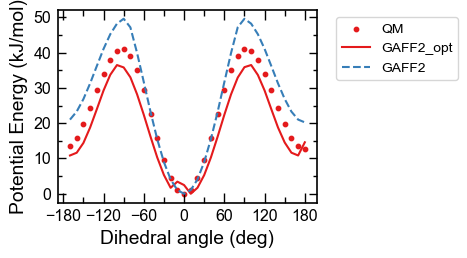

In [13]:
qm_pot_kjmol, qm_angle, qm_dihedatoms, dihed_atidx = get_qm_dihedral("dmc_dihed_0.log")
ff_pot_kjmol = scan_ff_dihedral("dmc.xml", top, qm_angle, qm_dihedatoms, dihed_atidx)
ff_pot_kjmol_opt = scan_ff_dihedral("best.xml", top, qm_angle, qm_dihedatoms, dihed_atidx)

import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(4/1.2, 3/1.2))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.set_xticks(range(-180, 181, 60))
ax.scatter(qm_angle, qm_pot_kjmol, label="QM", s=10)
ax.plot(qm_angle, ff_pot_kjmol_opt, label="GAFF2_opt")
ax.plot(qm_angle, ff_pot_kjmol, label="GAFF2", linestyle="--")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0))
ax.set_xlabel("Dihedral angle (deg)")
ax.set_ylabel("Potential Energy (kJ/mol)")
plt.show()

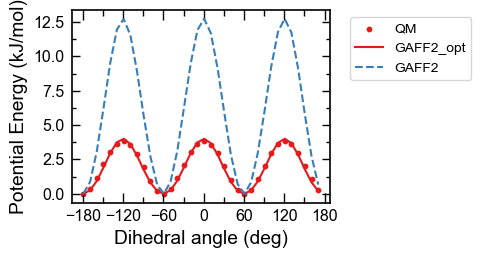

In [14]:
qm_pot_kjmol, qm_angle, qm_dihedatoms, dihed_atidx = get_qm_dihedral("dmc_dihed_2.log")
ff_pot_kjmol = scan_ff_dihedral("dmc.xml", top, qm_angle, qm_dihedatoms, dihed_atidx)
ff_pot_kjmol_opt = scan_ff_dihedral("best.xml", top, qm_angle, qm_dihedatoms, dihed_atidx)

import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(4/1.2, 3/1.2))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.set_xticks(range(-180, 181, 60))
ax.scatter(qm_angle, qm_pot_kjmol, label="QM", s=10)
ax.plot(qm_angle, ff_pot_kjmol_opt, label="GAFF2_opt")
ax.plot(qm_angle, ff_pot_kjmol, label="GAFF2", linestyle="--")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0))
ax.set_xlabel("Dihedral angle (deg)")
ax.set_ylabel("Potential Energy (kJ/mol)")
plt.show()